# Stroke Prediction Model 

### Background
According to the World Health Organization (WHO), stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

### Importing Relevant Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Loading and Initial Exploration of Stroke Prediction Dataset 

In [3]:
# Load the dataset
filepath = 'healthcare-dataset-stroke-data.csv'
try:
    df = pd.read_csv(filepath)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Dataset file not found. Please download from Kaggle and update the file path.")
    print("For now, we'll create a sample dataset to demonstrate the concepts.")

Dataset loaded successfully!


In [4]:
# Preview the dataset
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.shape

(5110, 12)

In [5]:
print("\n" + "-"*80)
print("COLUMN INFORMATION")
print("-"*80)
df.info()


--------------------------------------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)

In [7]:
print("\n" + "-"*80)
print("STATISTICAL SUMMARY")
print("-"*80)
df.describe()


--------------------------------------------------------------------------------
STATISTICAL SUMMARY
--------------------------------------------------------------------------------


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Feature Understanding

In [6]:
# Check data types
print("\nNumerical Features:")
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numerical_features:
    numerical_features.remove('id')
if 'stroke' in numerical_features:
    numerical_features.remove('stroke')
print(numerical_features)


Numerical Features:
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [7]:
print("\nCategorical Features:")
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_features)


Categorical Features:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [11]:
print("\nTarget Variable:")
print("stroke (binary: 0 = No stroke, 1 = Stroke)")


Target Variable:
stroke (binary: 0 = No stroke, 1 = Stroke)


In [8]:
# Check for missing values
print("\n" + "="*80)
print("MISSING DATA ANALYSIS")
print("="*80)
missing_data = df.isnull().sum()
missing_percent = 100 * missing_data / len(df)
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
missing_df


MISSING DATA ANALYSIS


,Missing_Count,Percentage
bmi,201,3.933464


In [9]:
if len(missing_df) > 0:
    print("\n⚠ Features with missing values:")
    print(missing_df)
else:
    print("\n✓ No missing values detected!")


⚠ Features with missing values:
     Missing_Count  Percentage
bmi            201    3.933464


In [10]:
# Check target variable distribution
print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)
target_counts = df['stroke'].value_counts()
target_percent = 100 * df['stroke'].value_counts(normalize=True)

print("\nStroke Occurrence:")
print(f"  No Stroke (0): {target_counts[0]:,} ({target_percent[0]:.2f}%)")
print(f"  Stroke (1):    {target_counts[1]:,} ({target_percent[1]:.2f}%)")
print(f"\n  Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f}:1")


TARGET VARIABLE DISTRIBUTION

Stroke Occurrence:
  No Stroke (0): 4,861 (95.13%)
  Stroke (1):    249 (4.87%)

  Imbalance Ratio: 19.5:1


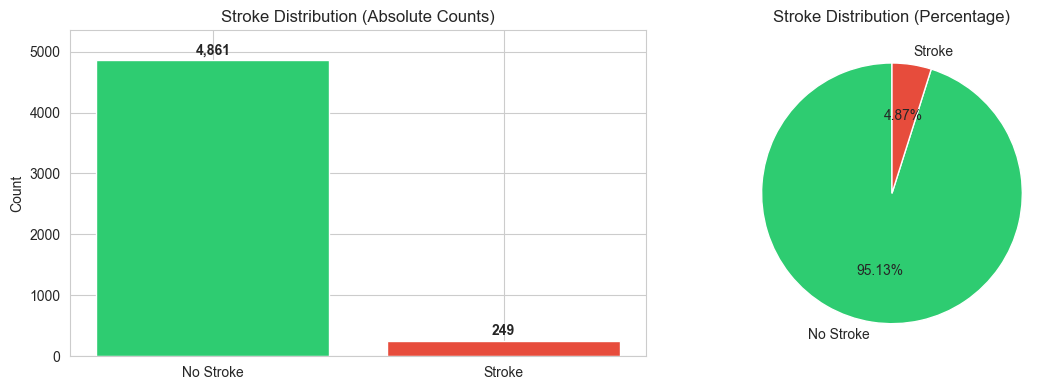

In [11]:
# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(['No Stroke', 'Stroke'], target_counts.values, color=['#2ecc71', '#e74c3c'])
ax[0].set_ylabel('Count')
ax[0].set_title('Stroke Distribution (Absolute Counts)')
ax[0].set_ylim(0, max(target_counts.values) * 1.1)
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + max(target_counts.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

ax[1].pie(target_counts.values, labels=['No Stroke', 'Stroke'], 
          autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Stroke Distribution (Percentage)')

plt.tight_layout()
plt.show()

This is a HIGHLY IMBALANCED dataset and will require special handling in modeling.

### Feature Engineering

In [12]:
# Create a copy for feature engineering
df_engineered = df.copy()

Technique 1: Creating Binary Flags (0/1 indicators) that signal the presence or absence of a condition

In [13]:
# Flag for elderly patients (age >= 65)
df_engineered['is_elderly'] = (df_engineered['age'] >= 65).astype(int)

# Flag for high glucose (prediabetic/diabetic range: >= 126 mg/dL fasting)
df_engineered['high_glucose'] = (df_engineered['avg_glucose_level'] >= 126).astype(int)

# Flag for obesity (BMI >= 30)
df_engineered['is_obese'] = (df_engineered['bmi'] >= 30).astype(int)

# Combined comorbidity flag (has hypertension OR heart disease)
df_engineered['has_comorbidity'] = ((df_engineered['hypertension'] == 1) | 
                                     (df_engineered['heart_disease'] == 1)).astype(int)

print("✓ Created binary flags:")
print("  - is_elderly: Age >= 65")
print("  - high_glucose: Avg glucose >= 126 mg/dL")
print("  - is_obese: BMI >= 30")
print("  - has_comorbidity: Hypertension OR heart disease")

✓ Created binary flags:
  - is_elderly: Age >= 65
  - high_glucose: Avg glucose >= 126 mg/dL
  - is_obese: BMI >= 30
  - has_comorbidity: Hypertension OR heart disease


In [14]:
# Show examples
print("\nExample rows with new flags:")
df_engineered[['age', 'is_elderly', 'avg_glucose_level', 'high_glucose', 
                     'bmi', 'is_obese', 'has_comorbidity']].head(10)


Example rows with new flags:


,age,is_elderly,avg_glucose_level,high_glucose,bmi,is_obese,has_comorbidity
0,67.0,1,228.69,1,36.6,1,1
1,61.0,0,202.21,1,NaN,0,0
2,80.0,1,105.92,0,32.5,1,1
3,49.0,0,171.23,1,34.4,1,0
4,79.0,1,174.12,1,24.0,0,1
5,81.0,1,186.21,1,29.0,0,0
6,74.0,1,70.09,0,27.4,0,1
7,69.0,1,94.39,0,22.8,0,0
8,59.0,0,76.15,0,NaN,0,0
9,78.0,1,58.57,0,24.2,0,0


Technique 2: Binning Continuous Variables to convert them into categorical groups

In [15]:
# Age groups (clinical age brackets)
df_engineered['age_group'] = pd.cut(df_engineered['age'], 
                                     bins=[0, 18, 35, 50, 65, 100],
                                     labels=['Child/Teen', 'Young Adult', 'Middle Age', 'Senior', 'Elderly'],
                                     right=False)

# BMI categories (WHO classification)
df_engineered['bmi_category'] = pd.cut(df_engineered['bmi'], 
                                        bins=[0, 18.5, 25, 30, 40, 100],
                                        labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severely Obese'],
                                        right=False)

# Glucose level categories
df_engineered['glucose_category'] = pd.cut(df_engineered['avg_glucose_level'],
                                            bins=[0, 100, 126, 200, 1000],
                                            labels=['Normal', 'Prediabetic', 'Diabetic', 'Very High'],
                                            right=False)

print("✓ Created categorical bins:")
print("  - age_group: 5 clinical age brackets")
print("  - bmi_category: WHO BMI classification")
print("  - glucose_category: Clinical glucose ranges")

✓ Created categorical bins:
  - age_group: 5 clinical age brackets
  - bmi_category: WHO BMI classification
  - glucose_category: Clinical glucose ranges


In [20]:
print("\nAge group distribution:")
age_group_tb = df_engineered['age_group'].value_counts().sort_index()
age_group_tb


Age group distribution:


age_group
Child/Teen      856
Young Adult     989
Middle Age     1055
Senior         1183
Elderly        1027
Name: count, dtype: int64

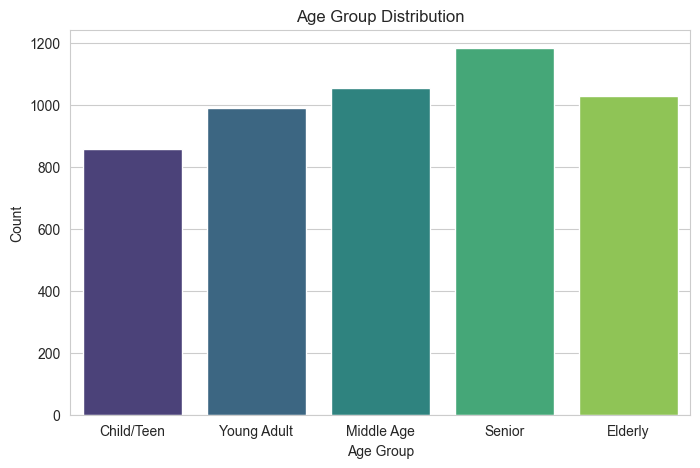

In [21]:
# Visualize age group distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=age_group_tb.index, y=age_group_tb.values, palette="viridis")
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [22]:
print("\nBMI category distribution:")
bmi_tb = df_engineered['bmi_category'].value_counts()
bmi_tb


BMI category distribution:


bmi_category
Obese             1506
Overweight        1409
Normal            1243
Severely Obese     414
Underweight        337
Name: count, dtype: int64

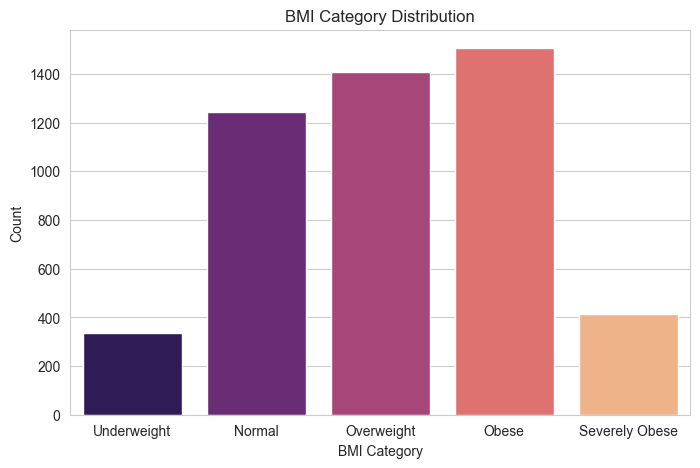

In [23]:
# visualize BMI category distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=bmi_tb.index, y=bmi_tb.values, palette="magma")
plt.title('BMI Category Distribution')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

In [24]:
print("\nGLucose category distribution:")
df_engineered['glucose_category'].value_counts()


GLucose category distribution:


glucose_category
Normal         3131
Prediabetic     998
Diabetic        547
Very High       434
Name: count, dtype: int64

Technique 3: Interaction Features to capture the combined effect of multiple variables

In [25]:
# High-risk combination: elderly with comorbidities
df_engineered['elderly_with_comorbidity'] = (
    (df_engineered['is_elderly'] == 1) & 
    (df_engineered['has_comorbidity'] == 1)
).astype(int)

# Multiple risk factors count
df_engineered['risk_factor_count'] = (
    df_engineered['hypertension'] + 
    df_engineered['heart_disease'] + 
    df_engineered['is_obese'] + 
    df_engineered['high_glucose']
)

# Smoking + hypertension (compounding cardiovascular risk)
df_engineered['smoker_with_hypertension'] = (
    ((df_engineered['smoking_status'] == 'smokes') | 
     (df_engineered['smoking_status'] == 'formerly smoked')) & 
    (df_engineered['hypertension'] == 1)
).astype(int)

print("✓ Created interaction features:")
print("  - elderly_with_comorbidity: Age 65+ AND (hypertension OR heart disease)")
print("  - risk_factor_count: Total number of major risk factors (0-4)")
print("  - smoker_with_hypertension: Smoking history AND hypertension")

✓ Created interaction features:
  - elderly_with_comorbidity: Age 65+ AND (hypertension OR heart disease)
  - risk_factor_count: Total number of major risk factors (0-4)
  - smoker_with_hypertension: Smoking history AND hypertension


In [26]:
print("\nRisk factor count distribution:")
df_engineered['risk_factor_count'].value_counts().sort_index()


Risk factor count distribution:


risk_factor_count
0    2460
1    1831
2     629
3     174
4      16
Name: count, dtype: int64

Technique 4: Handling Missing Data

In [27]:
# Check BMI missingness
bmi_missing_pct = 100 * df_engineered['bmi'].isnull().sum() / len(df_engineered)
print(f"\nBMI missing: {df_engineered['bmi'].isnull().sum()} rows ({bmi_missing_pct:.2f}%)")

if df_engineered['bmi'].isnull().sum() > 0:
    # Create flag for missing BMI (missingness might be informative)
    df_engineered['bmi_missing'] = df_engineered['bmi'].isnull().astype(int)
    
    # Impute with median (robust to outliers)
    bmi_median = df_engineered['bmi'].median()
    df_engineered['bmi_imputed'] = df_engineered['bmi'].fillna(bmi_median)
    
    print(f"✓ Created 'bmi_missing' flag")
    print(f"✓ Imputed missing BMI values with median: {bmi_median:.2f}")
    
    # Update derived features with imputed values
    df_engineered['is_obese'] = (df_engineered['bmi_imputed'] >= 30).astype(int)
    df_engineered['bmi_category'] = pd.cut(df_engineered['bmi_imputed'], 
                                            bins=[0, 18.5, 25, 30, 40, 100],
                                            labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severely Obese'],
                                            right=False)
    
    print("✓ Updated derived features (is_obese, bmi_category) using imputed values")


BMI missing: 201 rows (3.93%)
✓ Created 'bmi_missing' flag
✓ Imputed missing BMI values with median: 28.10
✓ Updated derived features (is_obese, bmi_category) using imputed values


Technique 5: Encoding Categorical Variables (Label Encoding for ordered categories, and One-Hot Encoding for unordered ones)

In [28]:
# Binary categorical variables (can use simple mapping)
df_engineered['gender_encoded'] = df_engineered['gender'].map({
    'Male': 1, 
    'Female': 0, 
    'Other': 2
})

df_engineered['ever_married_encoded'] = df_engineered['ever_married'].map({
    'Yes': 1, 
    'No': 0
})

df_engineered['residence_encoded'] = df_engineered['Residence_type'].map({
    'Urban': 1, 
    'Rural': 0
})

print("✓ Label encoded binary categorical variables:")
print("  - gender: Male=1, Female=0, Other=2")
print("  - ever_married: Yes=1, No=0")
print("  - Residence_type: Urban=1, Rural=0")

✓ Label encoded binary categorical variables:
  - gender: Male=1, Female=0, Other=2
  - ever_married: Yes=1, No=0
  - Residence_type: Urban=1, Rural=0


In [29]:
df_engineered['work_type'].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [30]:
# One-hot encoding for multi-category variables
# Work type
work_type_dummies = pd.get_dummies(df_engineered['work_type'], prefix='work', drop_first=True)
df_engineered = pd.concat([df_engineered, work_type_dummies], axis=1)

# Smoking status
smoking_dummies = pd.get_dummies(df_engineered['smoking_status'], prefix='smoking', drop_first=True)
df_engineered = pd.concat([df_engineered, smoking_dummies], axis=1)

print("\n✓ One-hot encoded multi-category variables:")
print(f"  - work_type: Created {len(work_type_dummies.columns)} binary columns")
print(f"  - smoking_status: Created {len(smoking_dummies.columns)} binary columns")
print("\nNote: Using drop_first=True to avoid multicollinearity (dummy variable trap)")


✓ One-hot encoded multi-category variables:
  - work_type: Created 4 binary columns
  - smoking_status: Created 3 binary columns

Note: Using drop_first=True to avoid multicollinearity (dummy variable trap)


Technique 6: Feature Scaling/Normalization (Can use Z-score nomalisation or Min-Max scaling))


In [31]:
# Select numerical features for scaling
features_to_scale = ['age', 'avg_glucose_level', 'bmi_imputed']

# Standardization
scaler = StandardScaler()

'''
df_engineered[['age_scaled', 'glucose_scaled', 'bmi_scaled']] = scaler.fit_transform(
    df_engineered[features_to_scale]
) '''
# Fit and transform, then wrap in a DataFrame
scaled_values = scaler.fit_transform(df_engineered[features_to_scale])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=['age_scaled', 'glucose_scaled', 'bmi_scaled'],
    index=df_engineered.index  # keeps same row alignment
)

# Join scaled features to the main DataFrame
df_engineered = pd.concat([df_engineered, scaled_df], axis=1)

print("✓ Applied standardization (Z-score) to continuous features:")
print("  - age → age_scaled")
print("  - avg_glucose_level → glucose_scaled")
print("  - bmi_imputed → bmi_scaled")

✓ Applied standardization (Z-score) to continuous features:
  - age → age_scaled
  - avg_glucose_level → glucose_scaled
  - bmi_imputed → bmi_scaled


In [32]:
print("\nBefore and after scaling example:")
comparison = df_engineered[['age', 'age_scaled', 'avg_glucose_level', 
                            'glucose_scaled', 'bmi_imputed', 'bmi_scaled']].head()
comparison


Before and after scaling example:


,age,age_scaled,avg_glucose_level,glucose_scaled,bmi_imputed,bmi_scaled
0,67.0,1.051434,228.69,2.706375,36.6,1.005086
1,61.0,0.786070,202.21,2.121559,28.1,-0.098981
2,80.0,1.626390,105.92,-0.005028,32.5,0.472536
3,49.0,0.255342,171.23,1.437358,34.4,0.719327
4,79.0,1.582163,174.12,1.501184,24.0,-0.631531


Technique 7: Domain-Specific Features

In [33]:
# Cardiovascular risk score (simplified)
# Combines multiple risk factors with clinical relevance
df_engineered['cv_risk_score'] = (
    (df_engineered['age'] / 10) +  # Age contribution
    (df_engineered['hypertension'] * 2) +  # Hypertension doubles risk
    (df_engineered['heart_disease'] * 3) +  # Heart disease triples risk
    (df_engineered['is_obese'] * 1.5) +  # Obesity adds significant risk
    ((df_engineered['smoking_status'].isin(['smokes', 'formerly smoked'])).astype(int) * 2)  # Smoking doubles
)

# Metabolic syndrome indicators (simplified criteria)
# Typically: obesity + high glucose + hypertension
df_engineered['metabolic_syndrome_indicator'] = (
    (df_engineered['is_obese'] == 1) & 
    (df_engineered['high_glucose'] == 1) & 
    (df_engineered['hypertension'] == 1)
).astype(int)

print("✓ Created domain-specific features:")
print("  - cv_risk_score: Composite cardiovascular risk score")
print("  - metabolic_syndrome_indicator: Simplified metabolic syndrome flag")

print("\nCardiovascular risk score distribution:")
print(df_engineered['cv_risk_score'].describe())


✓ Created domain-specific features:
  - cv_risk_score: Composite cardiovascular risk score
  - metabolic_syndrome_indicator: Simplified metabolic syndrome flag

Cardiovascular risk score distribution:
count    5110.000000
mean        5.898395
std         3.350029
min         0.008000
25%         3.400000
50%         6.000000
75%         8.200000
max        16.500000
Name: cv_risk_score, dtype: float64


### Feature Importance Review

Before modeling, let's examine how our engineered features relate to stroke occurrence.
This helps us:
1. Validate our feature engineering
2. Identify potentially important predictors
3. Spot issues or surprises
4. Build intuition for modeling


Top features correlated with stroke:
is_elderly                      0.247136
age                             0.245257
cv_risk_score                   0.233832
has_comorbidity                 0.171871
risk_factor_count               0.144355
heart_disease                   0.134914
avg_glucose_level               0.131945
hypertension                    0.127904
high_glucose                    0.120463
metabolic_syndrome_indicator    0.076593
Name: stroke, dtype: float64


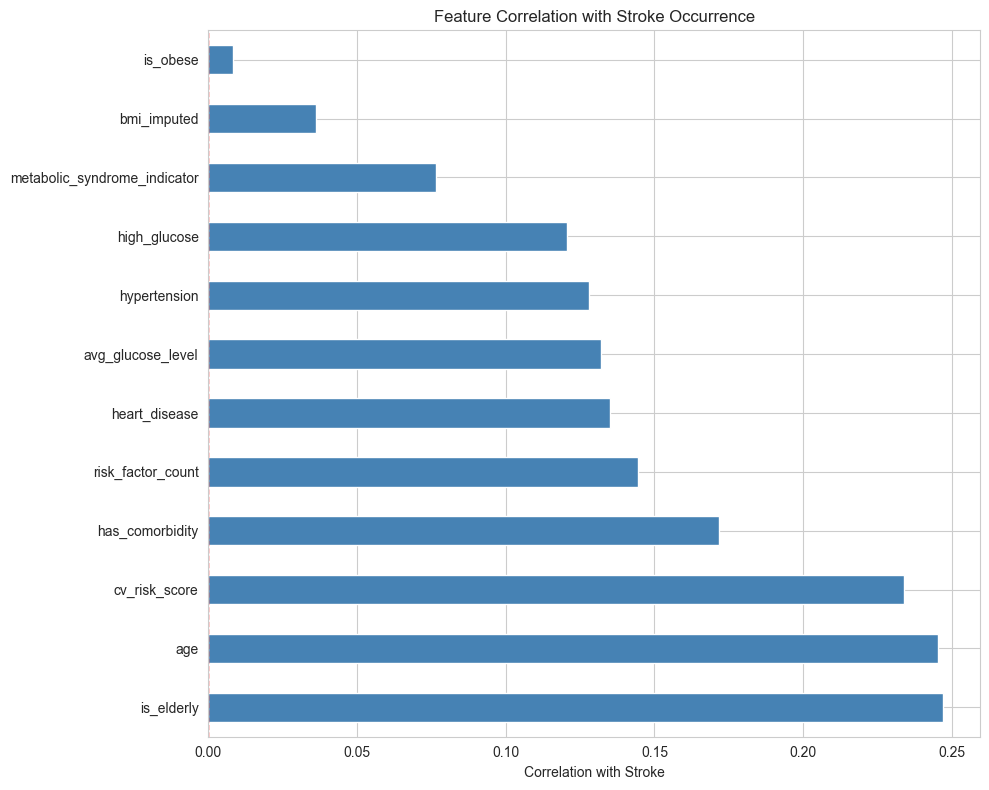

In [34]:
# Select key features for analysis
analysis_features = [
    'age', 'is_elderly', 'hypertension', 'heart_disease', 
    'has_comorbidity', 'avg_glucose_level', 'high_glucose',
    'bmi_imputed', 'is_obese', 'risk_factor_count', 
    'cv_risk_score', 'metabolic_syndrome_indicator'
]

# Calculate correlation with stroke
correlations = df_engineered[analysis_features + ['stroke']].corr()['stroke'].drop('stroke').sort_values(ascending=False)

print("\nTop features correlated with stroke:")
print(correlations.head(10))

# Visualize feature importance through correlation
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Stroke')
plt.title('Feature Correlation with Stroke Occurrence')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [35]:
# Compare stroke rates across categorical features
print("\n" + "-"*80)
print("Stroke rates by category:")
print("-"*80)

# Age group
stroke_by_age = df_engineered.groupby('age_group')['stroke'].agg(['mean', 'count'])
stroke_by_age.columns = ['Stroke_Rate', 'Count']
stroke_by_age['Stroke_Rate'] = stroke_by_age['Stroke_Rate'] * 100
print("\nBy Age Group:")
print(stroke_by_age)

# Comorbidity
stroke_by_comorbidity = df_engineered.groupby('has_comorbidity')['stroke'].mean() * 100
print("\nBy Comorbidity Status:")
print("No comorbidity: {:.2f}%".format(stroke_by_comorbidity[0]))
print("Has comorbidity: {:.2f}%".format(stroke_by_comorbidity[1]))


--------------------------------------------------------------------------------
Stroke rates by category:
--------------------------------------------------------------------------------

By Age Group:
             Stroke_Rate  Count
age_group                      
Child/Teen      0.233645    856
Young Adult     0.101112    989
Middle Age      1.611374   1055
Senior          5.917160   1183
Elderly        15.481986   1027

By Comorbidity Status:
No comorbidity: 3.39%
Has comorbidity: 14.08%


In [36]:
# Risk factor count
stroke_by_risk_count = df_engineered.groupby('risk_factor_count')['stroke'].mean() * 100
print("\nBy Number of Risk Factors:")
for i, rate in stroke_by_risk_count.items():
    print(f"{i} risk factors: {rate:.2f}%")


By Number of Risk Factors:
0 risk factors: 2.97%
1 risk factors: 4.31%
2 risk factors: 10.17%
3 risk factors: 16.09%
4 risk factors: 31.25%


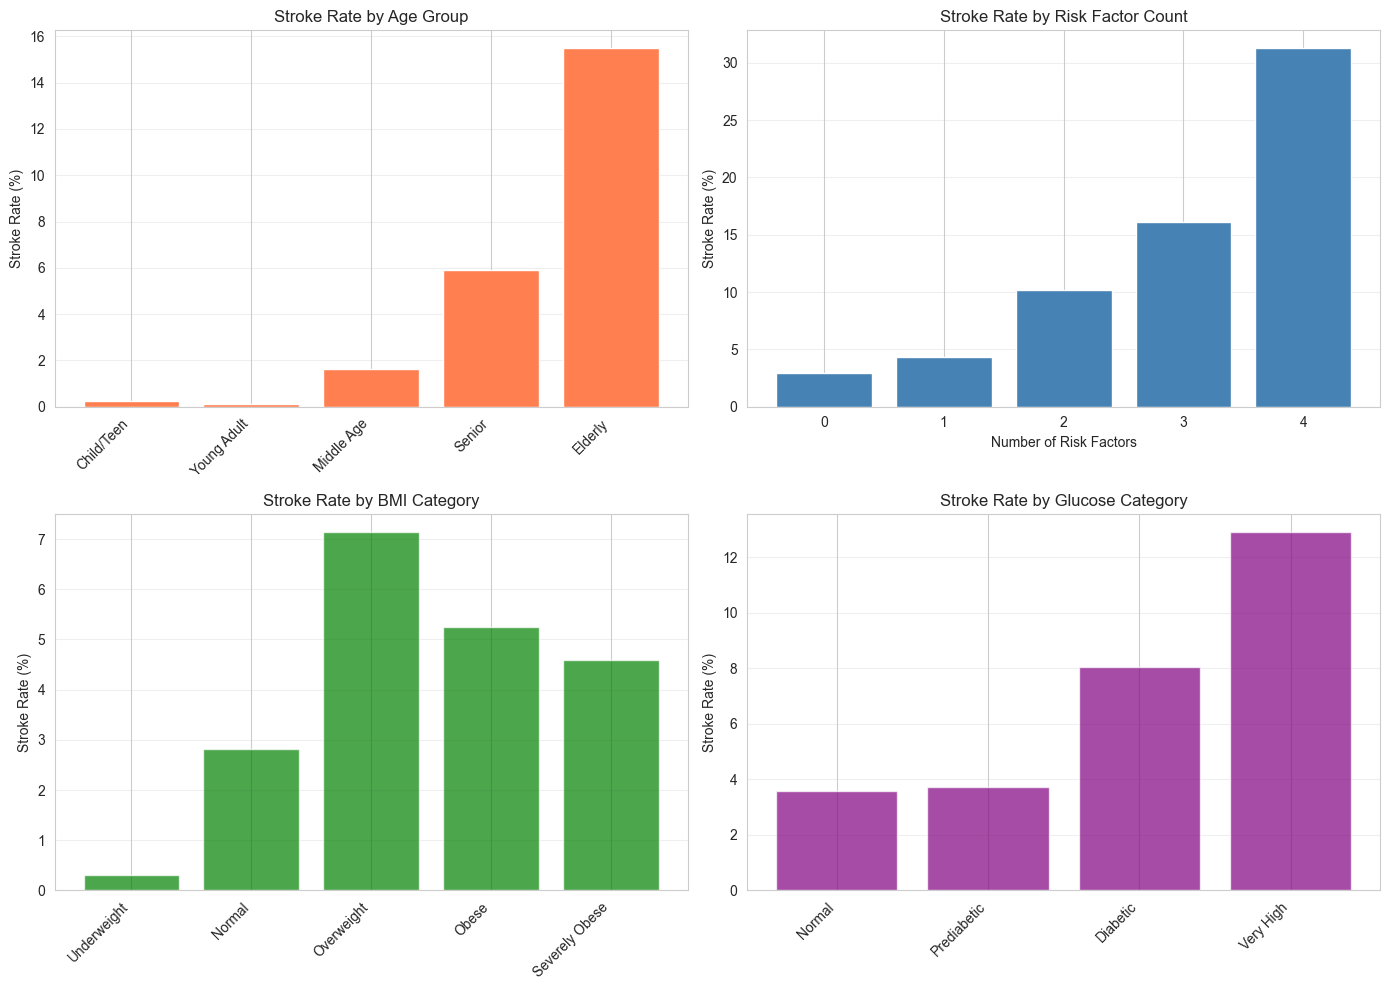

In [37]:
# Visualization: Stroke rate by key categories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age group
stroke_by_age_plot = df_engineered.groupby('age_group')['stroke'].mean() * 100
axes[0, 0].bar(range(len(stroke_by_age_plot)), stroke_by_age_plot.values, color='coral')
axes[0, 0].set_xticks(range(len(stroke_by_age_plot)))
axes[0, 0].set_xticklabels(stroke_by_age_plot.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Stroke Rate (%)')
axes[0, 0].set_title('Stroke Rate by Age Group')
axes[0, 0].grid(axis='y', alpha=0.3)

# Risk factor count
axes[0, 1].bar(stroke_by_risk_count.index, stroke_by_risk_count.values, color='steelblue')
axes[0, 1].set_xlabel('Number of Risk Factors')
axes[0, 1].set_ylabel('Stroke Rate (%)')
axes[0, 1].set_title('Stroke Rate by Risk Factor Count')
axes[0, 1].grid(axis='y', alpha=0.3)

# BMI category
stroke_by_bmi = df_engineered.groupby('bmi_category')['stroke'].mean() * 100
axes[1, 0].bar(range(len(stroke_by_bmi)), stroke_by_bmi.values, color='green', alpha=0.7)
axes[1, 0].set_xticks(range(len(stroke_by_bmi)))
axes[1, 0].set_xticklabels(stroke_by_bmi.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Stroke Rate (%)')
axes[1, 0].set_title('Stroke Rate by BMI Category')
axes[1, 0].grid(axis='y', alpha=0.3)

# Glucose category
stroke_by_glucose = df_engineered.groupby('glucose_category')['stroke'].mean() * 100
axes[1, 1].bar(range(len(stroke_by_glucose)), stroke_by_glucose.values, color='purple', alpha=0.7)
axes[1, 1].set_xticks(range(len(stroke_by_glucose)))
axes[1, 1].set_xticklabels(stroke_by_glucose.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Stroke Rate (%)')
axes[1, 1].set_title('Stroke Rate by Glucose Category')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Prepare the Final Feature Set

Now that we've engineered our features, we need to:
1. Select which features to include in our model
2. Ensure all features are in the correct format
3. Handle any remaining data quality issues
4. Split into training and testing sets

In [38]:
# Define our final feature set
final_features = [
    # Original features (encoded)
    'age',
    'gender_encoded',
    'hypertension',
    'heart_disease',
    'ever_married_encoded',
    'residence_encoded',
    'avg_glucose_level',
    'bmi_imputed',
    
    # Engineered binary flags
    'is_elderly',
    'high_glucose',
    'is_obese',
    'has_comorbidity',
    'elderly_with_comorbidity',
    'smoker_with_hypertension',
    'metabolic_syndrome_indicator',
    'bmi_missing',
    
    # Engineered numeric features
    'risk_factor_count',
    'cv_risk_score',
    
    # One-hot encoded features
    'work_Govt_job',
    'work_Never_worked',
    'work_Private',
    'work_Self-employed',
    'smoking_formerly smoked',
    'smoking_never smoked',
    'smoking_smokes'
]

In [39]:
# Verify all features exist
missing_features = [f for f in final_features if f not in df_engineered.columns]
if missing_features:
    print(f"Warning: These features are missing: {missing_features}")
    final_features = [f for f in final_features if f in df_engineered.columns]

print(f"\n✓ Final feature set contains {len(final_features)} features")
print("\nFeature categories:")
print(f"  - Original encoded features: 8")
print(f"  - Engineered flags: 8")
print(f"  - Engineered numeric: 2")
print(f"  - One-hot encoded: {len([f for f in final_features if 'work_' in f or 'smoking_' in f])}")


✓ Final feature set contains 24 features

Feature categories:
  - Original encoded features: 8
  - Engineered flags: 8
  - Engineered numeric: 2
  - One-hot encoded: 6


In [40]:
# Create final dataset
X = df_engineered[final_features].copy()
y = df_engineered['stroke'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Check for any remaining missing values
remaining_missing = X.isnull().sum().sum()
if remaining_missing > 0:
    print(f"\n⚠ Warning: {remaining_missing} missing values remain")
    print("\nMissing values by feature:")
    print(X.isnull().sum()[X.isnull().sum() > 0])
else:
    print("\n✓ No missing values in final feature set!")


Feature matrix shape: (5110, 24)
Target vector shape: (5110,)

✓ No missing values in final feature set!


In [41]:
# Check for infinite values
inf_values = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
if inf_values > 0:
    print(f"\n⚠ Warning: {inf_values} infinite values detected")
else:
    print("✓ No infinite values detected!")

✓ No infinite values detected!


### Test - Train Split

In [42]:
# Stratified split (maintains class imbalance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n✓ Data split successfully!")
print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification worked
print("\nClass distribution in splits:")
print(f"\nOriginal data:")
print(f"  No Stroke: {(y==0).sum()} ({(y==0).mean()*100:.2f}%)")
print(f"  Stroke: {(y==1).sum()} ({(y==1).mean()*100:.2f}%)")

print(f"\nTraining set:")
print(f"  No Stroke: {(y_train==0).sum()} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Stroke: {(y_train==1).sum()} ({(y_train==1).mean()*100:.2f}%)")

print(f"\nTest set:")
print(f"  No Stroke: {(y_test==0).sum()} ({(y_test==0).mean()*100:.2f}%)")
print(f"  Stroke: {(y_test==1).sum()} ({(y_test==1).mean()*100:.2f}%)")


✓ Data split successfully!

Training set: 4088 samples (80.0%)
Test set: 1022 samples (20.0%)

Class distribution in splits:

Original data:
  No Stroke: 4861 (95.13%)
  Stroke: 249 (4.87%)

Training set:
  No Stroke: 3889 (95.13%)
  Stroke: 199 (4.87%)

Test set:
  No Stroke: 972 (95.11%)
  Stroke: 50 (4.89%)


### Applying Feature Scaling on Split Data
CRITICAL: Always fit scaler on training data ONLY, then transform both sets!

In [43]:
# Identify features that need scaling (continuous features)
features_needing_scaling = ['age', 'avg_glucose_level', 'bmi_imputed', 'cv_risk_score']
features_needing_scaling = [f for f in features_needing_scaling if f in X_train.columns]

# Create copies to preserve original
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler on training data ONLY
scaler_final = StandardScaler()
X_train_scaled[features_needing_scaling] = scaler_final.fit_transform(X_train[features_needing_scaling])

# Transform test data using training data statistics
X_test_scaled[features_needing_scaling] = scaler_final.transform(X_test[features_needing_scaling])

print(f"✓ Scaled {len(features_needing_scaling)} continuous features")
print(f"  Features scaled: {', '.join(features_needing_scaling)}")

print("\nScaling statistics (learned from training data):")
for feature, mean, std in zip(features_needing_scaling, scaler_final.mean_, scaler_final.scale_):
    print(f"  {feature}: mean={mean:.2f}, std={std:.2f}")

✓ Scaled 4 continuous features
  Features scaled: age, avg_glucose_level, bmi_imputed, cv_risk_score

Scaling statistics (learned from training data):
  age: mean=43.35, std=22.59
  avg_glucose_level: mean=106.32, std=45.25
  bmi_imputed: mean=28.89, std=7.76
  cv_risk_score: mean=5.91, std=3.34


### Build Models 

In [46]:
# Import relevant libraries
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

In [47]:
# Define Helper Function for Model Evaluation
def evaluate_model(model, X_train, y_train, X_test, y_test, use_smote=False):
    """
    Trains and evaluates a classification model.
    Optionally applies SMOTE for resampling imbalanced data.

    Parameters:
        model: scikit-learn model object
        X_train, y_train, X_test, y_test: training and testing sets
        use_smote: bool, whether to apply SMOTE (for KNN in this example)

    Returns:
        dict: containing model name and performance metrics
    """
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_pred)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
        'Confusion Metrix': confusion_matrix(y_test, y_pred)
    }

In [48]:
# Define Models to Compare
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', 
                        max_iter=1000, 
                        random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
                        max_depth=5,
                        min_samples_split=50,
                        min_samples_leaf=20,
                        random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',
                        n_estimators=100,
                        max_depth=10,
                        min_samples_split=50,
                        min_samples_leaf=20,
                        random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,
                        learning_rate=0.1,
                        max_depth=5,
                        min_samples_split=50,
                        min_samples_leaf=20,
                        random_state=42),
    'KNN (SMOTE)': KNeighborsClassifier(n_neighbors=5)
}

In [49]:
# Train and Evaluate All Models
results = []
for name, model in models.items():
    print(f"\nTraining {name}...")
    use_smote = True if 'KNN' in name else False
    metrics = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, use_smote)
    metrics['Model'] = name
    results.append(metrics)

print("\nAll models have been trained succesfully!")
# Convert results to DataFrame
results_df = pd.DataFrame(results)


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training KNN (SMOTE)...

All models have been trained succesfully!


In [51]:
# Display Model Comparison Summary
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))


MODEL COMPARISON SUMMARY
 Accuracy  Recall  Precision  F1-Score  AUC-ROC       Confusion Metrix               Model
 0.737769    0.80   0.134228  0.229885 0.834794 [[714, 258], [10, 40]] Logistic Regression
 0.808219    0.76   0.171171  0.279412 0.786204 [[788, 184], [12, 38]]       Decision Tree
 0.801370    0.80   0.171674  0.282686 0.828230 [[779, 193], [10, 40]]       Random Forest
 0.951076    0.04   0.500000  0.074074 0.817984    [[970, 2], [48, 2]]   Gradient Boosting
 0.825832    0.34   0.104938  0.160377 0.678889 [[827, 145], [33, 17]]         KNN (SMOTE)


<Figure size 1200x600 with 0 Axes>

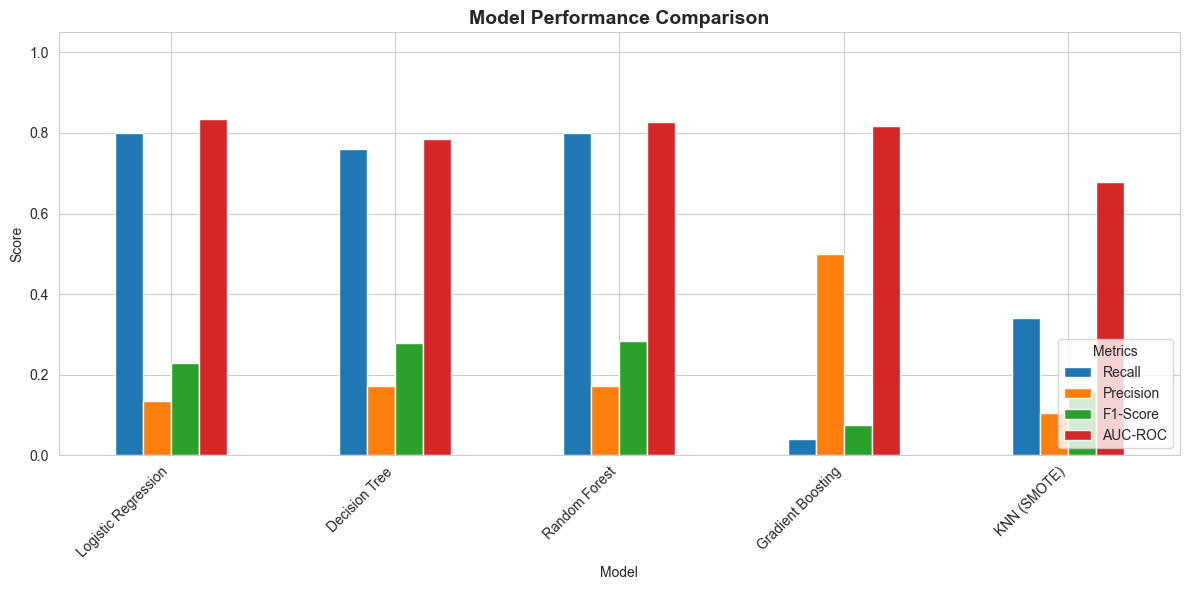

In [53]:
# Visualisation
plt.figure(figsize=(12, 6))
results_df.set_index('Model')[['Recall', 'Precision', 'F1-Score', 'AUC-ROC']].plot(
    kind='bar', figsize=(12, 6)
)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', loc='lower right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [52]:
# Save artifacts
import joblib

# Save model using joblib
joblib.dump('Random Forest', "random_forest_stroke_model.joblib")
print("Model saved successfully!")

Model saved successfully!
